# Seed-mix outside check: kMate vs hapFIRE founder frequencies

Independent validation of kMate's per-founder (ecotype) frequency on the 8 seed-mix reps against
**hapFIRE** (the phase-1 SNP-based estimator, run on the same seed-mix BAMs). The seed mix was built
from all 231 ecotypes in ~equal proportions, so the biological expectation is **h ≈ 1/231 = 0.00433**
for every founder.

**Question:** the kMate selection trait drops 19 founders whose estimated founding frequency `p0` is
≤1e-3. Are those founders really rare/unresolvable, or is kMate mis-estimating them?

**Plot:** founders ordered on the x-axis **low→high by the kMate estimate**; three series — expected
(1/231), hapFIRE, kMate.

> Env: **`kmate`** (matplotlib works here). Do **not** use the `plotting` env — matplotlib hangs there.
> `source ~/miniforge3/etc/profile.d/conda.sh && conda activate kmate`

In [1]:
import numpy as np, glob, os, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

PROJ = "/global/scratch/users/tbellg/kmate"
D = "/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix"
CHROMS = [f"Chr{i}" for i in range(1, 6)]
os.chdir(PROJ)

In [2]:
# ---- kMate: 8 reps x 5 chroms x 231 founders -> chrom-avg per rep -> mean over reps ----
reps = sorted({os.path.basename(p).split("_Chr")[0]
               for p in glob.glob("results/seedmix_kmate_arch3/*_Chr1.h_per_chrom.npz")})
founders = None
Hk = np.zeros((len(reps), 5, 231))
for ri, s in enumerate(reps):
    for ci, c in enumerate(CHROMS):
        z = np.load(f"results/seedmix_kmate_arch3/{s}_{c}.h_per_chrom.npz", allow_pickle=True)
        if founders is None:
            founders = z["founders"].astype(str)
        Hk[ri, ci] = z[c].astype(float)
kmate    = Hk.mean(1).mean(0)     # (231,) mean over reps of the chrom-averaged h
kmate_sd = Hk.mean(1).std(0)      # rep-to-rep sd

# ---- hapFIRE: 8 reps x 231 ecotype frequencies ----
hf = {i: {k: float(v) for k, v in np.loadtxt(f"{D}/s{i}_ecotype_frequency.txt", dtype=str)}
      for i in range(1, 9)}
hfm  = np.array([np.mean([hf[r][f] for r in range(1, 9)]) for f in founders])
hfsd = np.array([np.std ([hf[r][f] for r in range(1, 9)]) for f in founders])

exp = 1 / 231
print(f"founders: {len(founders)}   expected 1/231 = {exp:.5f}")
print(f"hapFIRE sum/rep (≈1): {np.round([sum(hf[i].values()) for i in range(1,9)], 3)}")

founders: 231   expected 1/231 = 0.00433
hapFIRE sum/rep (≈1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [3]:
# ---- agreement stats + the 19 kMate-dropped founders vs hapFIRE ----
r   = np.corrcoef(kmate, hfm)[0, 1]
rho = stats.spearmanr(kmate, hfm).correlation
print(f"Pearson r = {r:.3f}   Spearman rho = {rho:.3f}   log10 r = "
      f"{np.corrcoef(np.log10(kmate+1e-9), np.log10(hfm+1e-9))[0,1]:.3f}")
print(f"kMate  : median {np.median(kmate):.4f}  n<1e-3 {int((kmate<1e-3).sum())}  "
      f"n<1/462 {int((kmate<1/462).sum())}  CV {kmate.std()/kmate.mean():.2f}")
print(f"hapFIRE: median {np.median(hfm):.4f}  n<1e-3 {int((hfm<1e-3).sum())}  "
      f"n<1/462 {int((hfm<1/462).sum())}  CV {hfm.std()/hfm.mean():.2f}")

drop = np.where(kmate <= 1e-3)[0]
tbl = pd.DataFrame(dict(founder=founders[drop], kMate_p0=kmate[drop],
                        hapFIRE=hfm[drop], hapFIRE_sd=hfsd[drop])).sort_values("kMate_p0")
print(f"\n{len(drop)} founders kMate calls ≤1e-3 — hapFIRE says:")
tbl

Pearson r = 0.381   Spearman rho = 0.450   log10 r = 0.217
kMate  : median 0.0038  n<1e-3 19  n<1/462 49  CV 0.66
hapFIRE: median 0.0043  n<1e-3 0  n<1/462 7  CV 0.33

19 founders kMate calls ≤1e-3 — hapFIRE says:


,founder,kMate_p0,hapFIRE,hapFIRE_sd
16,9977,2.920570e-15,0.002353,0.001068
18,9985,5.819093e-08,0.008324,0.005461
14,9941,1.107040e-06,0.004260,0.001463
6,10013,1.193555e-06,0.004072,0.001685
7,9507,1.208428e-06,0.003283,0.000471
17,9978,3.061799e-05,0.003022,0.001758
13,9748,1.031159e-04,0.004687,0.001142
15,9966,1.682082e-04,0.005536,0.001812
12,9743,2.468043e-04,0.003736,0.000519
10,9739,2.830073e-04,0.002634,0.000095


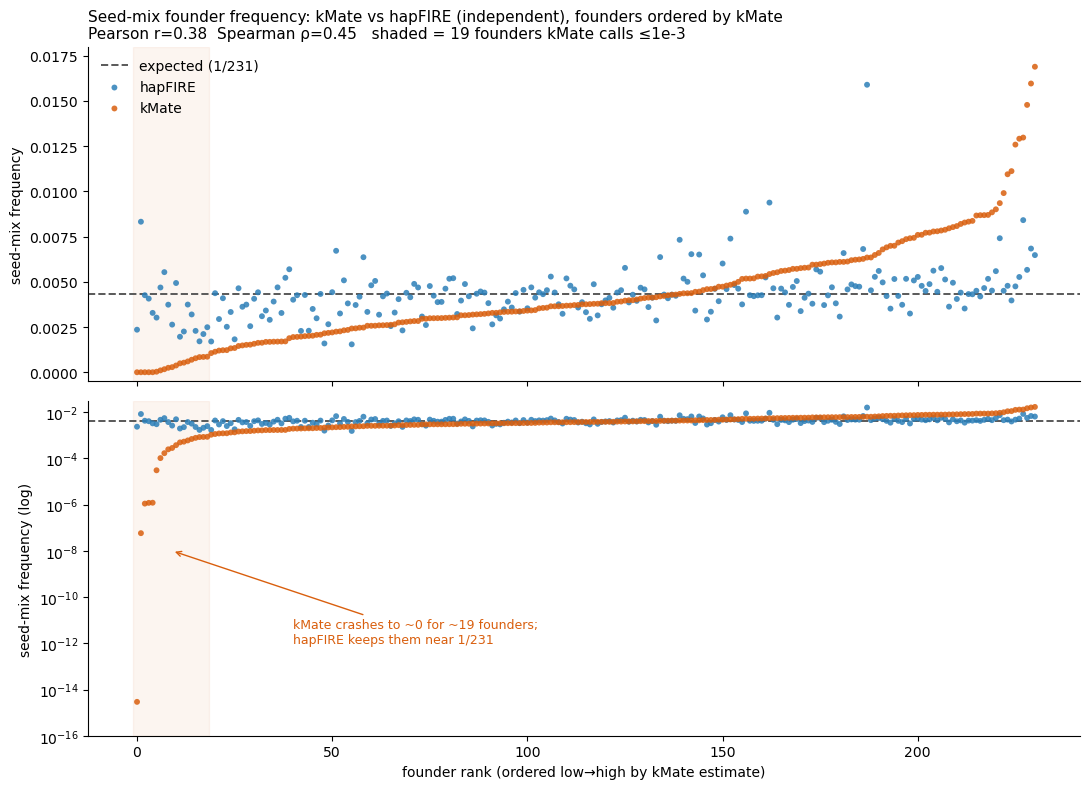

In [4]:
# ---- the plot: founders ordered low->high by kMate; expected / hapFIRE / kMate ----
o = np.argsort(kmate)
x = np.arange(231)
n_drop = int((kmate <= 1e-3).sum())

fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for a, logy in zip(ax, (False, True)):
    a.axhline(exp, color="0.35", ls="--", lw=1.4, zorder=1, label="expected (1/231)")
    a.scatter(x, hfm[o],   s=18, c="#2c7fb8", alpha=.85, edgecolors="none", zorder=3, label="hapFIRE")
    a.scatter(x, kmate[o], s=18, c="#d95f0e", alpha=.85, edgecolors="none", zorder=4, label="kMate")
    a.axvspan(-1, n_drop - 0.5, color="#d95f0e", alpha=.06, zorder=0)
    a.set_ylabel("seed-mix frequency" + (" (log)" if logy else ""))
    a.spines[["top", "right"]].set_visible(False)
    if logy:
        a.set_yscale("log"); a.set_ylim(1e-16, 3e-2)
    else:
        a.set_ylim(-0.0005, 0.018)
ax[0].legend(frameon=False, loc="upper left", fontsize=10)
ax[0].set_title(f"Seed-mix founder frequency: kMate vs hapFIRE (independent), founders ordered by kMate\n"
                f"Pearson r={r:.2f}  Spearman ρ={rho:.2f}   shaded = {n_drop} founders kMate calls ≤1e-3",
                loc="left", fontsize=11)
ax[1].set_xlabel("founder rank (ordered low→high by kMate estimate)")
ax[1].annotate("kMate crashes to ~0 for ~19 founders;\nhapFIRE keeps them near 1/231",
               xy=(9, 1e-8), xytext=(40, 1e-12), fontsize=9, color="#d95f0e",
               arrowprops=dict(arrowstyle="->", color="#d95f0e", lw=1))
fig.tight_layout()
os.makedirs("analysis/grenenet_gea/seedmix_validation", exist_ok=True)
fig.savefig("analysis/grenenet_gea/seedmix_validation/seedmix_kmate_vs_hapfire.png", dpi=150)
plt.show()

## Read-out

- **hapFIRE stays in a flat band around 1/231 regardless of the kMate rank** — the blue cloud has no
  slope, so the two methods are essentially **decoupled** on the founder-mixture decomposition
  (Pearson r ≈ 0.38). hapFIRE has **0** founders below 1e-3; kMate has **19**.
- The 19 founders kMate calls ≤0 (incl. `9977` at ~3e-15) are read **normal** by hapFIRE, and never
  low in any of its 8 reps — so they are genuinely present at ~1/231. kMate under-calls them
  (twin-absorption / mixture non-identifiability) and dumps the mass onto a handful of "absorber"
  founders on the right (kMate up to 0.017 vs hapFIRE ~0.006).
- kMate's spread is inflated (CV 0.66 vs hapFIRE 0.33).

**Implication:** dropping founders on kMate `p0` is wrong — they are real. The trait's founding anchor
should use 1/231 (or hapFIRE), keeping all 231. More importantly, kMate resolves *allele* frequencies
well (validated r≈0.98) but the *founder* decomposition poorly (r≈0.38) — so the per-founder selection
trait needs the slope-vs-slope check at the evolved timepoints before it is trusted.